In [5]:
from modeller import *

env = Environ()
#env.io.atom_files_directory = ['/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/target/1-loopmodel']
env.io.atom_files_directory = ['.']
env.io.hetatm = False
env.io.water = False

aln = Alignment(env)

# Sequence from PDB (ucr2+lr2)
mdl = Model(env, file='4X0F_nohetatm')
aln.append_model(mdl, align_codes='4X0F_nohetatm', atom_files='4X0F_nohetatm.pdb')

# Target sequence (without mutations WT) from .ali 
aln.append(file='structures.ali', align_codes='target')

# 2D alignment
aln.align2d(max_gap_length=50)

# Save
aln.write(file='structures_align2d.ali', alignment_format='PIR')
aln.write(file='structures_align2d.pap', alignment_format='PAP')  

mkapsa__637W> No residue topology library is in memory.
              Better radii would be used if topology.read() is called first.
iup2crm_280W> No topology library in memory or assigning a BLK residue.
              Default CHARMM atom type assigned:  N -->  N
              This message is written only for the first such atom.

Pairwise dynamic programming alignment (ALIGN2D):
  Residue-residue metric   : $(LIB)/as1.sim.mat
  Diagonal                 :          100
  Overhang                 :            0
  Maximal gap length       :           50
  Local alignment          :            F
  MATRIX_OFFSET (local aln):       0.0000
  FIX_OFFSETS              :      0.0    -1.0    -2.0    -3.0    -4.0
  N_SUBOPT                 :            0
  SUBOPT_OFFSET            :       0.0000
  Alignment block          :            1
  Gap introduction penalty :    -100.0000
  Gap extension penalty    :       0.0000
  Gap diagonal penalty     :       0.0000
  Structure gap penalties  :    3.500

In [7]:
from modeller import *

class MyModel(LoopModel):

    def select_loop_atoms(self):
        return Selection(self.residue_range('20:A', '57:A'),
                          self.residue_range('117:A', '160:A'))

    def select_atoms(self):
        # nada excluído da otimização — todos os átomos entram
        return Selection(self)

    def special_restraints(self, aln):
        rsr = self.restraints

        # resíduos próximos das bordas do loop -> só CA (mais liberdade)
        residuos_proximos = [
            '109:A', '113:A', '114:A', '354:A',
        ]

        # resíduos distantes das bordas -> backbone inteiro (mais rígido)
        residuos_distantes = [
            '240:A', '241:A', 
            '400:A', '402:A', '410:A',
            '413:A', '414:A', '417:A',
            '418:A', '421:A', '438:A',
            '449:A', '450:A', '453:A'
        ]

        def tether_atoms(res_ids, atom_names, stdev):
            for r in res_ids:
                res = self.residues[r]
                for atom_name in atom_names:
                    if atom_name in res.atoms:
                        atom = res.atoms[atom_name]
                        rsr.add(
                            forms.Gaussian(
                                group=physical.xy_distance,
                                feature=features.Distance(atom, atom),
                                mean=0.0,
                                stdev=stdev
                            )
                        )

        # próximos do loop: só CA, mola um pouco mais frouxa
        tether_atoms(residuos_proximos, ('CA',), stdev=0.15)

        # distantes: backbone inteiro, mola mais rígida
        tether_atoms(residuos_distantes, ('N', 'CA', 'C', 'O'), stdev=0.05)


a = MyModel(
    env,
    alnfile  = 'structures_align2d.ali',
    knowns   = '4X0F_nohetatm',
    sequence = 'target'
    
)
 
a.starting_model = 1
a.ending_model   = 1

a.loop.starting_model = 1
a.loop.ending_model   = 50             
a.loop.md_level       = refine.very_slow 

a.make()

NameError: name 'LoopModel' is not defined

In [ ]:
# from modeller.automodel import *

# class MyModel(LoopModel):

#     def select_loop_atoms(self):
#         return Selection(self.residue_range('20:A', '57:A'),
#                          self.residue_range('117:A', '160:A')
#                          )

#     def select_atoms(self):
#         todos_atomos = Selection(self)

#         residuos_fixos = [
#             '109:A', '113:A', '114:A',
#             '240:A', '241:A', '354:A',
#             '400:A', '402:A', '410:A',
#             '413:A', '414:A', '417:A',
#             '418:A', '421:A', '438:A',
#             '449:A', '450:A', '453:A'
#         ]

#         selecao_fixos = Selection([self.residues[r] for r in residuos_fixos])

#         return todos_atomos - selecao_fixos


check_ali___> Checking the sequence-structure alignment. 

Implied intrachain target CA(i)-CA(i+1) distances longer than  8.0 angstroms:

ALN_POS  TMPL  RID1  RID2  NAM1  NAM2     DIST
----------------------------------------------
     57     1  184   223      T     L    8.137
    117     1  282   326      K     Q   41.632
END OF TABLE
read_to_681_> topology.submodel read from topology file:        3
mdtrsr__446W> A potential that relies on one protein is used, yet you have at
              least one known structure available. MDT, not library, potential is used.
0 atoms in HETATM/BLK residues constrained
to protein atoms within 2.30 angstroms
and protein CA atoms within 10.00 angstroms
0 atoms in residues without defined topology
constrained to be rigid bodies
condens_443_> Restraints marked for deletion were removed.
              Total number of restraints before, now:    45729    42184
3792 (of 3962 total) atoms selected for optimization
iupac_m_397W> Atoms were not swapped becau

In [1]:
from modeller import *
from modeller.scripts import complete_pdb
import glob
import os

log.verbose()
env = Environ()
env.libs.topology.read(file='$(LIB)/top_heav.lib')
env.libs.parameters.read(file='$(LIB)/par.lib')

modelling_dir = '.'

# Get files
model_files = sorted(
    glob.glob(os.path.join(modelling_dir, 'target.BL*.pdb'))
)


                         MODELLER 10.7, 2025/05/28, r13093

     PROTEIN STRUCTURE MODELLING BY SATISFACTION OF SPATIAL RESTRAINTS


                     Copyright(c) 1989-2025 Andrej Sali
                            All Rights Reserved

                             Written by A. Sali
                               with help from
              B. Webb, M.S. Madhusudhan, M-Y. Shen, G.Q. Dong,
          M.A. Marti-Renom, N. Eswar, F. Alber, M. Topf, B. Oliva,
             A. Fiser, R. Sanchez, B. Yerkovich, A. Badretdinov,
                     F. Melo, J.P. Overington, E. Feyfant
                 University of California, San Francisco, USA
                    Rockefeller University, New York, USA
                      Harvard University, Cambridge, USA
                   Imperial Cancer Research Fund, London, UK
              Birkbeck College, University of London, London, UK


Kind, OS, HostName, Kernel, Processor: 4, Windows 10 build 26200, VSAW, SMP, x64
Date and time of compilation

In [2]:
len(model_files)

50

In [3]:
scores = []

# Save scores and profiles
for model_path in model_files:
    base_name = os.path.splitext(os.path.basename(model_path))[0]
    profile_file = os.path.join(modelling_dir, f'{base_name}.profile')
       
    mdl = complete_pdb(env, model_path)
    s = Selection(mdl)
    
    score = s.assess_dope()
    scores.append((score, base_name, profile_file))
    
    s.assess_dope(output='ENERGY_PROFILE NO_REPORT',
                  file=profile_file,
                  normalize_profile=True,
                  smoothing_window=15)

openf___224_> Open           .\target.BL00010001.pdb

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       445487     435.046     0.425

Dynamically allocated memory at    amaxsequence [B,KiB,MiB]:       445563     435.120     0.425

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       445734     435.287     0.425

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       446584     436.117     0.426

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       447842     437.346     0.427

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       449746     439.205     0.429

Dynamically allocated memory at    amaxsequence [B,KiB,MiB]:       449786     439.244     0.429

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       449876     439.332     0.429

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       452732     442.121     0.432

Dynamically allocated memory at    amaxsequence [B,KiB,MiB]:       452792

In [5]:

# Ranking final
print("\n Ranking - DOPE score")
for score, name, profile in sorted(scores[1:50]):
    print(f"  {name:40s}  DOPE: {score:.2f}")

best = sorted(scores)[0]
print(f"\nBest: {best[1]}  (DOPE: {best[0]:.2f})")



 Ranking - DOPE score
  target.BL00350001                         DOPE: -53378.52
  target.BL00160001                         DOPE: -52766.54
  target.BL00110001                         DOPE: -52507.74
  target.BL00040001                         DOPE: -52226.18
  target.BL00120001                         DOPE: -52189.36
  target.BL00140001                         DOPE: -52123.38
  target.BL00300001                         DOPE: -52010.68
  target.BL00190001                         DOPE: -51913.72
  target.BL00250001                         DOPE: -51771.97
  target.BL00420001                         DOPE: -51642.04
  target.BL00360001                         DOPE: -51563.68
  target.BL00100001                         DOPE: -51434.31
  target.BL00070001                         DOPE: -51421.86
  target.BL00500001                         DOPE: -51179.79
  target.BL00060001                         DOPE: -50822.54
  target.BL00030001                         DOPE: -50726.62
  target.BL000800

In [7]:
sorted(scores)[:10]

[(-53378.515625, 'target.BL00350001', '.\\target.BL00350001.profile'),
 (-52766.53515625, 'target.BL00160001', '.\\target.BL00160001.profile'),
 (-52507.7421875, 'target.BL00110001', '.\\target.BL00110001.profile'),
 (-52226.17578125, 'target.BL00040001', '.\\target.BL00040001.profile'),
 (-52189.35546875, 'target.BL00120001', '.\\target.BL00120001.profile'),
 (-52123.375, 'target.BL00140001', '.\\target.BL00140001.profile'),
 (-52010.68359375, 'target.BL00300001', '.\\target.BL00300001.profile'),
 (-51913.72265625, 'target.BL00190001', '.\\target.BL00190001.profile'),
 (-51771.97265625, 'target.BL00250001', '.\\target.BL00250001.profile'),
 (-51642.0390625, 'target.BL00420001', '.\\target.BL00420001.profile')]

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import re
import numpy as np

#modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/target/1-loopmodelling'
modelling_dir = "."
profiles_with_sum = []
profile_files = sorted(glob.glob(os.path.join(modelling_dir, '*.profile')))
for profile_path in profile_files:
    total_sum = None
    with open(profile_path, 'r') as f:
        for line in f:
            match = re.search(r'The sum of all numbers in the file:\s+([-\d.]+)', line)
            if match:
                total_sum = float(match.group(1))
                break
    
    profiles_with_sum.append((profile_path, total_sum))

# Sort from smaller to bigger
profiles_with_sum.sort(key=lambda x: x[1], reverse=True)
top10 = profiles_with_sum[-10:]  # Last 1o (smaller values)

In [9]:
top10

[('.\\target.BL00120001.profile', -15.6818),
 ('.\\target.BL00160001.profile', -15.7706),
 ('.\\target.BL00350001.profile', -15.7839),
 ('.\\target.BL00420001.profile', -15.845),
 ('.\\target.BL00010001.profile', -16.0024),
 ('.\\target.BL00070001.profile', -16.0817),
 ('.\\target.BL00040001.profile', -16.0879),
 ('.\\target.BL00110001.profile', -16.2845),
 ('.\\target.BL00300001.profile', -16.3238),
 ('.\\target.BL00250001.profile', -16.4065)]

<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
C:\Users\vitor\AppData\Local\Temp\ipykernel_22012\1868983304.py:13: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(profile_path, sep='\s+', comment='#', header=None)


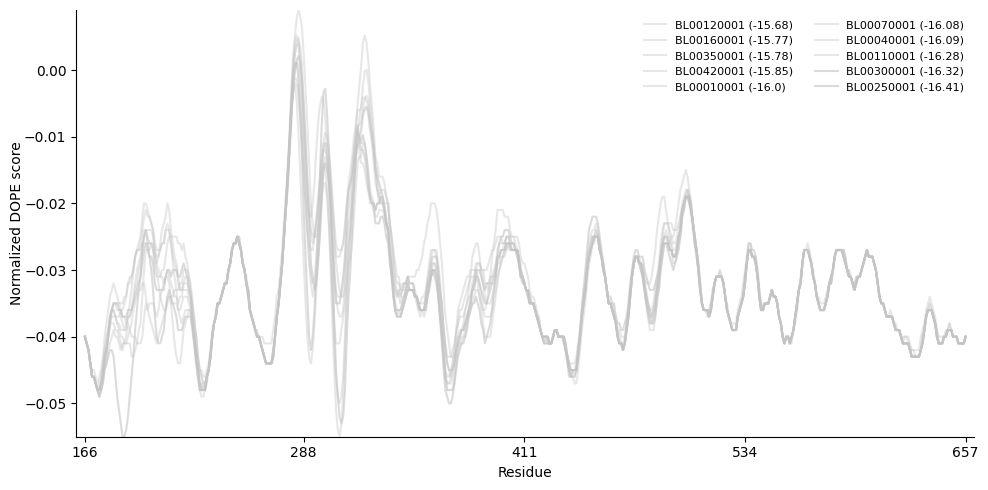

In [10]:

cinza = "#c4c4c4"
verde = '#6FAF9C'
roxo = '#A665B5'
# colors = [cinza] * 8 + [verde] * 2
colors = [cinza] *10

plt.figure(figsize=(10, 5))

all_dope = []
for i, (profile_path, total_sum) in enumerate(top10):

    name = os.path.basename(profile_path).replace('.profile', '').replace('target.', '')
    df = pd.read_csv(profile_path, sep='\s+', comment='#', header=None)
    residues = df[0] + 165
    dope=df[df.columns[-1]]
    all_dope.extend(dope.tolist())
    label = f'{name} ({round(total_sum, 2)})'    

    if i == 9 or i == 8:
        alpha = 0.6
    else:
        alpha = 0.4

    plt.plot(residues, dope, label=label, color=colors[i], alpha=alpha, )

# Scaling
plt.ylim(min(all_dope), max(all_dope))

plt.xlabel('Residue')
plt.ylabel('Normalized DOPE score', labelpad=0)

plt.title('')
plt.legend(fontsize=8,frameon=False, ncol=2)
ax = plt.gca()
plt.margins(x=0.01)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

first = residues.iloc[0]
last = residues.iloc[-1]
ticks = [first] + list(np.linspace(first, last, 5).astype(int)[1:-1]) + [last]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks)

plt.tight_layout()
#plt.savefig(os.path.join(modelling_dir, 'dope_profiles.png'), dpi=150)
plt.show() 

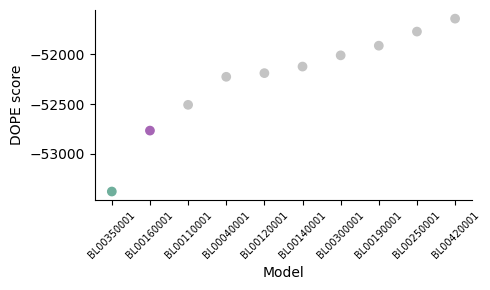

In [11]:
import matplotlib.pyplot as plt

# Ordenar do pior para o melhor (melhor fica à direita)
scores_sorted = sorted(scores, key=lambda x: x[0], reverse=False)
top10_scores = scores_sorted[:10]

names = [s[1].replace('target.', '').replace('.pdb', '') for s in top10_scores]

dopes = [s[0] for s in top10_scores]

# Destacar o melhor (último)
colors = [verde] + [roxo] + [cinza] * 8

fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(range(len(top10_scores)), dopes, color=colors, zorder=3)

ax.set_xlabel('Model')
ax.set_ylabel('DOPE score')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, fontsize=7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig(os.path.join(modelling_dir, 'dope_total.png'), dpi=150)
plt.show()

In [44]:
def renumber_pdb(input_pdb, output_pdb, start):
    with open(input_pdb, 'r') as f:
        lines = f.readlines()
    
    current_resnum = None
    new_resnum = start - 1
    
    with open(output_pdb, 'w') as out:
        for line in lines:
            if line.startswith(('ATOM', 'HETATM')):
                res = line[22:26].strip()
                if res != current_resnum:
                    current_resnum = res
                    new_resnum += 1
                line = line[:22] + f'{new_resnum:4d}' + line[26:]
            out.write(line)

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join/'

In [45]:
renumber_pdb(
        input_pdb="/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join/target.B99990042.pdb",
        output_pdb=modelling_dir + f"modelo_42.pdb",
        start=216
    )

In [ ]:
env = environ()
aln = alignment(env)
mdl = model(env, file='template')
aln.append_model(mdl, align_codes='template', atom_files='template.pdb')
aln.append(file='target.ali', align_codes='target')
aln.align2d()  # alinhamento baseado em estrutura, melhor que align()
aln.write(file='aln_refined.ali')